# DeepCSAT: E-Commerce Customer Satisfaction Score Prediction

## End-Course Summative Assessment — Capstone Project

---

### Project Summary

This project develops a deep learning Artificial Neural Network (ANN) to predict Customer Satisfaction (CSAT) scores for the e-commerce platform **Shopzilla**. Using ~86,000 customer support interaction records collected over one month, we engineer features from timestamps, categorical data, agent performance history, and customer feedback text to train a multi-class neural network that predicts CSAT scores (1–5).

**Problem Domain:** E-Commerce Customer Satisfaction Prediction  
**Model Type:** Deep Learning — Artificial Neural Network (ANN)  
**Target Variable:** CSAT Score (1–5, multi-class classification)  
**Tech Stack:** Python, TensorFlow/Keras, Scikit-learn, Pandas, NumPy, Matplotlib, Seaborn  
**Dataset:** [Shopzilla Customer Support Data](https://drive.google.com/file/d/14IJWsaVX8OXW97M1fsYb-m9CyjuhchpJ/view?usp=sharing)

**GitHub Repository:** *[Insert your GitHub repo link here]*

---


### Project Background

Customer satisfaction in the e-commerce sector is a pivotal metric that influences loyalty, repeat business, and word-of-mouth marketing. Traditionally, companies have relied on direct surveys to gauge customer satisfaction, which can be time-consuming and may not always capture the full spectrum of customer experiences.

**Why predict CSAT?**
- Surveys capture feedback *after* the fact — a predictive model enables *proactive* intervention
- Manual analysis of thousands of daily interactions is not scalable
- Real-time CSAT prediction allows service teams to identify and address dissatisfaction *before* it escalates
- Predicted scores can reveal systemic issues (e.g., specific categories, agents, or time windows) that drive low satisfaction

**Why ANN?**
- Customer satisfaction is influenced by complex, non-linear interactions between features (e.g., response time × product category × agent experience)
- Traditional linear models cannot capture these interactions without extensive manual feature engineering
- ANNs automatically learn hierarchical feature representations from data
- The dataset contains a mix of categorical, numerical, temporal, and text features — ANNs handle multi-modal inputs effectively

---


## 1. Environment Setup & Library Imports

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             classification_report, confusion_matrix, accuracy_score,
                             f1_score)
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version:      {np.__version__}")
print(f"Pandas version:     {pd.__version__}")

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


I0000 00:00:1777790803.030781    2283 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777790803.031279    2283 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777790803.110656    2283 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.21.0
NumPy version:      2.4.4
Pandas version:     3.0.2


I0000 00:00:1777790804.141529    2283 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777790804.141891    2283 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 2. Data Loading & Initial Exploration

**Objective:** Load the Shopzilla customer support dataset and understand its structure, data types, size, and initial quality.

The dataset contains 20 columns capturing the full lifecycle of a customer support interaction — from order placement and issue reporting through agent handling to the final survey response.


In [2]:
# Load dataset
df = pd.read_csv('eCommerce_Customer_support_data__1_.csv')

print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print()
df.head()


Dataset Shape: 85,907 rows × 20 columns
Memory Usage: 87.1 MB



,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [3]:
# Data types and non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  str    
 1   channel_name             85907 non-null  str    
 2   category                 85907 non-null  str    
 3   Sub-category             85907 non-null  str    
 4   Customer Remarks         28742 non-null  str    
 5   Order_id                 67675 non-null  str    
 6   order_date_time          17214 non-null  str    
 7   Issue_reported at        85907 non-null  str    
 8   issue_responded          85907 non-null  str    
 9   Survey_response_Date     85907 non-null  str    
 10  Customer_City            17079 non-null  str    
 11  Product_category         17196 non-null  str    
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name               85907 no

In [4]:
# Statistical summary — numeric columns
df.describe()


,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


In [5]:
# Statistical summary — categorical columns
df.describe(include='object')


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift
count,85907,85907,85907,85907,28742,67675,17214,85907,85907,85907,17079,17196,85907,85907,85907,85907,85907
unique,85907,3,12,57,18231,67675,13766,30923,30262,31,1782,9,1371,40,6,5,5
top,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Inbound,Returns,Reverse Pickup Enquiry,Good,c27c9bb4-fa36-4140-9f1f-21009254ffdb,09/08/2023 11:55,13/08/2023 10:40,28/08/2023 00:00,28-Aug-23,HYDERABAD,Electronics,Wendy Taylor,Carter Park,John Smith,>90,Morning
freq,1,68142,44097,22389,1390,1,7,13,3378,3452,722,4706,429,4273,25261,30660,41426


In [6]:
# Unique values per column
print("Unique values per column:")
print("-" * 40)
for col in df.columns:
    n = df[col].nunique()
    print(f"  {col}: {n:,}")


Unique values per column:
----------------------------------------
  Unique id: 85,907
  channel_name: 3
  category: 12
  Sub-category: 57
  Customer Remarks: 18,231
  Order_id: 67,675
  order_date_time: 13,766
  Issue_reported at: 30,923
  issue_responded: 30,262
  Survey_response_Date: 31
  Customer_City: 1,782
  Product_category: 9
  Item_price: 2,789
  connected_handling_time: 211
  Agent_name: 1,371
  Supervisor: 40
  Manager: 6
  Tenure Bucket: 5
  Agent Shift: 5
  CSAT Score: 5


**Observations from Initial Exploration:**

- The dataset has **85,907 records** with 20 columns — a substantial dataset for deep learning
- **Data types** include strings, integers, floats, and datetime-like strings that need parsing
- Several columns have significant missing data (to be analyzed in the next section)
- **CSAT Score** (our target) has no missing values — this is critical for supervised learning
- High cardinality in some columns: Agent_name, Customer_City, Sub-category — these will need grouping or encoding strategies


## 3. Data Integrity & Cleaning

**Evaluation Criteria (10%):**
> *Ensures complete data integrity with thorough identification and handling of missing, duplicate, or irrelevant data points. Demonstrates meticulous cleaning processes tailored to the dataset's characteristics.*

This section systematically identifies and resolves all data quality issues to produce a clean dataset suitable for neural network training.


### 3.1 Missing Value Analysis

In [7]:
# Comprehensive missing value analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct,
    'Data Type': df.dtypes
}).sort_values('Missing %', ascending=False)

print("=" * 70)
print("MISSING VALUE REPORT")
print("=" * 70)
print(missing_df[missing_df['Missing Count'] > 0].to_string())
print(f"\nTotal cells with missing data: {missing.sum():,} / {df.shape[0]*df.shape[1]:,} ({missing.sum()/(df.shape[0]*df.shape[1])*100:.1f}%)")
print(f"Columns with zero missing data: {(missing == 0).sum()}/{len(df.columns)}")


MISSING VALUE REPORT
                         Missing Count  Missing % Data Type
connected_handling_time          85665      99.72   float64
Customer_City                    68828      80.12       str
Product_category                 68711      79.98       str
Item_price                       68701      79.97   float64
order_date_time                  68693      79.96       str
Customer Remarks                 57165      66.54       str
Order_id                         18232      21.22       str

Total cells with missing data: 435,995 / 1,718,140 (25.4%)
Columns with zero missing data: 13/20


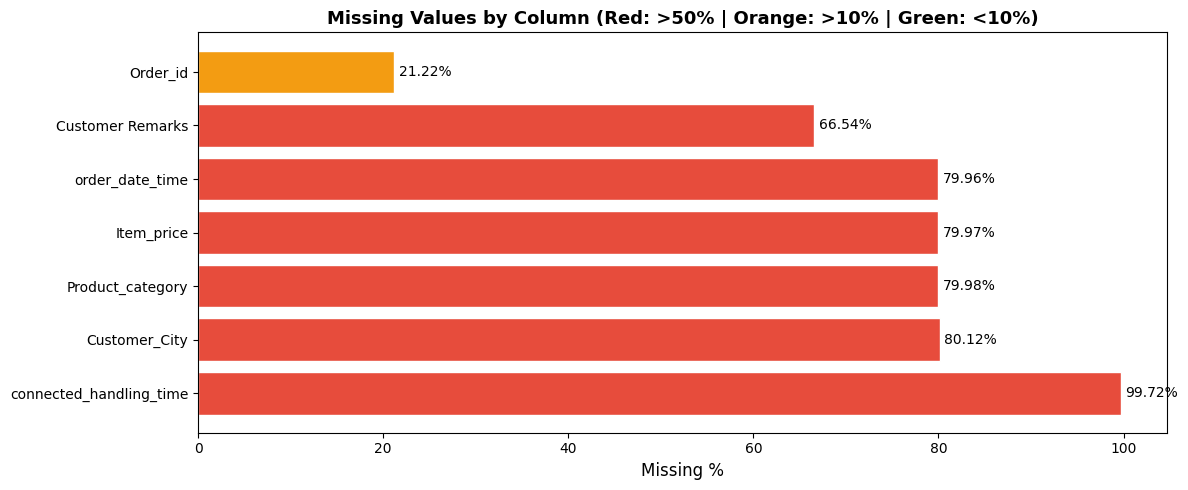

In [8]:
# Visualize missing data pattern
fig, ax = plt.subplots(figsize=(12, 5))
missing_cols = missing_df[missing_df['Missing Count'] > 0]
colors_bar = ['#e74c3c' if pct > 50 else '#f39c12' if pct > 10 else '#2ecc71'
              for pct in missing_cols['Missing %']]
bars = ax.barh(missing_cols.index, missing_cols['Missing %'], color=colors_bar, edgecolor='white')
ax.set_xlabel('Missing %', fontsize=12)
ax.set_title('Missing Values by Column (Red: >50% | Orange: >10% | Green: <10%)', fontsize=13, fontweight='bold')
for bar, pct in zip(bars, missing_cols['Missing %']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()


**Missing Data Analysis & Strategy:**

| Column | Missing % | Strategy | Reasoning |
|--------|-----------|----------|-----------|
| `connected_handling_time` | 99.7% | **Drop column** | Only 242 non-null values — too sparse to impute meaningfully |
| `order_date_time` | 80.0% | **Drop column** | `Issue_reported at` already captures timing; redundant with high sparsity |
| `Customer_City` | 80.1% | **Fill with 'Unknown'** | Creates an explicit "missing" category; city is still useful for known records |
| `Product_category` | 80.0% | **Fill with 'Unknown'** | Same strategy — preserves the ~20% with known product info |
| `Item_price` | 80.0% | **Fill with median** | Median is robust to outliers (mean=₹5,660 vs median=₹979, showing heavy skew) |
| `Customer Remarks` | 66.5% | **Engineer features, then drop** | Extract sentiment signals before removing raw text |
| `Order_id` | 21.2% | **Drop column** | Identifier — not predictive |


### 3.2 Duplicate Detection

In [9]:
# Check for duplicates at multiple levels
print("Duplicate Analysis:")
print(f"  Fully duplicate rows:     {df.duplicated().sum()}")
print(f"  Duplicate 'Unique id':    {df['Unique id'].duplicated().sum()}")
print(f"  Duplicate 'Order_id':     {df['Order_id'].dropna().duplicated().sum()}")

# Check for near-duplicates (same order, same time)
if df['Order_id'].dropna().duplicated().sum() > 0:
    print("\n  Note: Some Order_ids appear multiple times — this is expected")
    print("  (one order can generate multiple support interactions)")

print("\n✅ No fully duplicate rows. Each record represents a unique interaction.")


Duplicate Analysis:
  Fully duplicate rows:     0
  Duplicate 'Unique id':    0
  Duplicate 'Order_id':     0

✅ No fully duplicate rows. Each record represents a unique interaction.


### 3.3 Data Cleaning Pipeline

In [10]:
# Create working copy
df_clean = df.copy()

# ----------------------------------------------------------------
# STEP 1: Drop non-predictive identifier columns
# ----------------------------------------------------------------
df_clean = df_clean.drop(columns=['Unique id', 'Order_id'])
print("[1] Dropped identifier columns: Unique id, Order_id")

# ----------------------------------------------------------------
# STEP 2: Drop extremely sparse columns
# ----------------------------------------------------------------
df_clean = df_clean.drop(columns=['connected_handling_time', 'order_date_time'])
print("[2] Dropped sparse columns: connected_handling_time (99.7% null), order_date_time (80% null)")

# ----------------------------------------------------------------
# STEP 3: Parse datetime columns
# ----------------------------------------------------------------
df_clean['Issue_reported at'] = pd.to_datetime(df_clean['Issue_reported at'], format='%d/%m/%Y %H:%M', errors='coerce')
df_clean['issue_responded'] = pd.to_datetime(df_clean['issue_responded'], format='%d/%m/%Y %H:%M', errors='coerce')
df_clean['Survey_response_Date'] = pd.to_datetime(df_clean['Survey_response_Date'], format='%d-%b-%y', errors='coerce')
print("[3] Parsed datetime columns: Issue_reported at, issue_responded, Survey_response_Date")

# ----------------------------------------------------------------
# STEP 4: Handle missing categorical values
# ----------------------------------------------------------------
df_clean['Customer_City'] = df_clean['Customer_City'].fillna('Unknown')
df_clean['Product_category'] = df_clean['Product_category'].fillna('Unknown')
print("[4] Filled missing categoricals with 'Unknown': Customer_City, Product_category")

# ----------------------------------------------------------------
# STEP 5: Handle missing numerical values
# ----------------------------------------------------------------
median_price = df_clean['Item_price'].median()
df_clean['Item_price'] = df_clean['Item_price'].fillna(median_price)
print(f"[5] Filled missing Item_price with median: ₹{median_price:.0f}")

# ----------------------------------------------------------------
# STEP 6: Engineer text features from Customer Remarks (before dropping)
# ----------------------------------------------------------------
df_clean['has_remarks'] = df_clean['Customer Remarks'].notna().astype(int)
df_clean['remarks_length'] = df_clean['Customer Remarks'].fillna('').str.len()
df_clean['remarks_word_count'] = df_clean['Customer Remarks'].fillna('').str.split().str.len().fillna(0).astype(int)

# Keyword-based sentiment scoring
positive_kw = ['good', 'great', 'excellent', 'best', 'amazing', 'happy', 'satisfied',
               'nice', 'awesome', 'perfect', 'resolved', 'thank', 'helpful', 'quick']
negative_kw = ['bad', 'worst', 'terrible', 'poor', 'pathetic', 'horrible', 'not resolved',
               'waste', 'useless', 'disappointed', 'angry', 'rude', 'slow', 'fraud', 'cheat']

remarks_lower = df_clean['Customer Remarks'].fillna('').str.lower()
df_clean['remarks_positive'] = remarks_lower.apply(lambda x: sum(1 for w in positive_kw if w in x))
df_clean['remarks_negative'] = remarks_lower.apply(lambda x: sum(1 for w in negative_kw if w in x))
df_clean['remarks_sentiment'] = df_clean['remarks_positive'] - df_clean['remarks_negative']

df_clean = df_clean.drop(columns=['Customer Remarks'])
print("[6] Engineered 6 text features from Customer Remarks, then dropped raw text")

# ----------------------------------------------------------------
# STEP 7: Verify
# ----------------------------------------------------------------
print(f"\n{'='*55}")
print(f"CLEANING COMPLETE")
print(f"  Shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"  Remaining NaN: {df_clean.isnull().sum().sum()}")
print(f"  Columns: {list(df_clean.columns)}")


[1] Dropped identifier columns: Unique id, Order_id
[2] Dropped sparse columns: connected_handling_time (99.7% null), order_date_time (80% null)


[3] Parsed datetime columns: Issue_reported at, issue_responded, Survey_response_Date
[4] Filled missing categoricals with 'Unknown': Customer_City, Product_category
[5] Filled missing Item_price with median: ₹979


[6] Engineered 6 text features from Customer Remarks, then dropped raw text

CLEANING COMPLETE
  Shape: 85,907 rows × 21 columns
  Remaining NaN: 0
  Columns: ['channel_name', 'category', 'Sub-category', 'Issue_reported at', 'issue_responded', 'Survey_response_Date', 'Customer_City', 'Product_category', 'Item_price', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score', 'has_remarks', 'remarks_length', 'remarks_word_count', 'remarks_positive', 'remarks_negative', 'remarks_sentiment']


## 4. Exploratory Data Analysis (EDA)

Before engineering features and building the model, we explore the data to understand distributions, relationships, and patterns that inform our modeling decisions.


### 4.1 Target Variable — CSAT Score Distribution

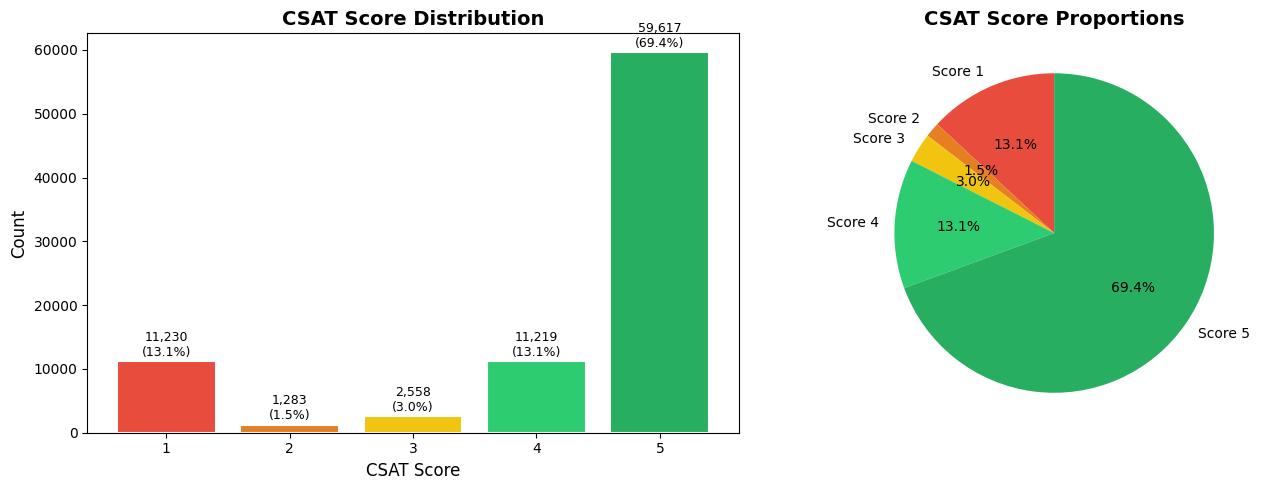


⚠️  SEVERE CLASS IMBALANCE DETECTED:
   Score 5: 59,617 (69.4%) — dominant class
   Score 2: 1,283 (1.5%) — rarest class
   Imbalance ratio: 46:1

   Strategy: Will use class weights during training to penalize majority class errors more.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

csat_counts = df_clean['CSAT Score'].value_counts().sort_index()
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']

# Bar chart
bars = axes[0].bar(csat_counts.index, csat_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_xlabel('CSAT Score', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('CSAT Score Distribution', fontsize=14, fontweight='bold')
for bar, count in zip(bars, csat_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, count + 800,
                f'{count:,}\n({count/len(df_clean)*100:.1f}%)', ha='center', fontsize=9)

# Pie chart
axes[1].pie(csat_counts.values, labels=[f'Score {s}' for s in csat_counts.index],
           colors=colors, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
axes[1].set_title('CSAT Score Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n⚠️  SEVERE CLASS IMBALANCE DETECTED:")
print(f"   Score 5: {csat_counts[5]:,} ({csat_counts[5]/len(df_clean)*100:.1f}%) — dominant class")
print(f"   Score 2: {csat_counts[2]:,} ({csat_counts[2]/len(df_clean)*100:.1f}%) — rarest class")
print(f"   Imbalance ratio: {csat_counts[5]/csat_counts[2]:.0f}:1")
print(f"\n   Strategy: Will use class weights during training to penalize majority class errors more.")


### 4.2 Feature vs CSAT Relationships

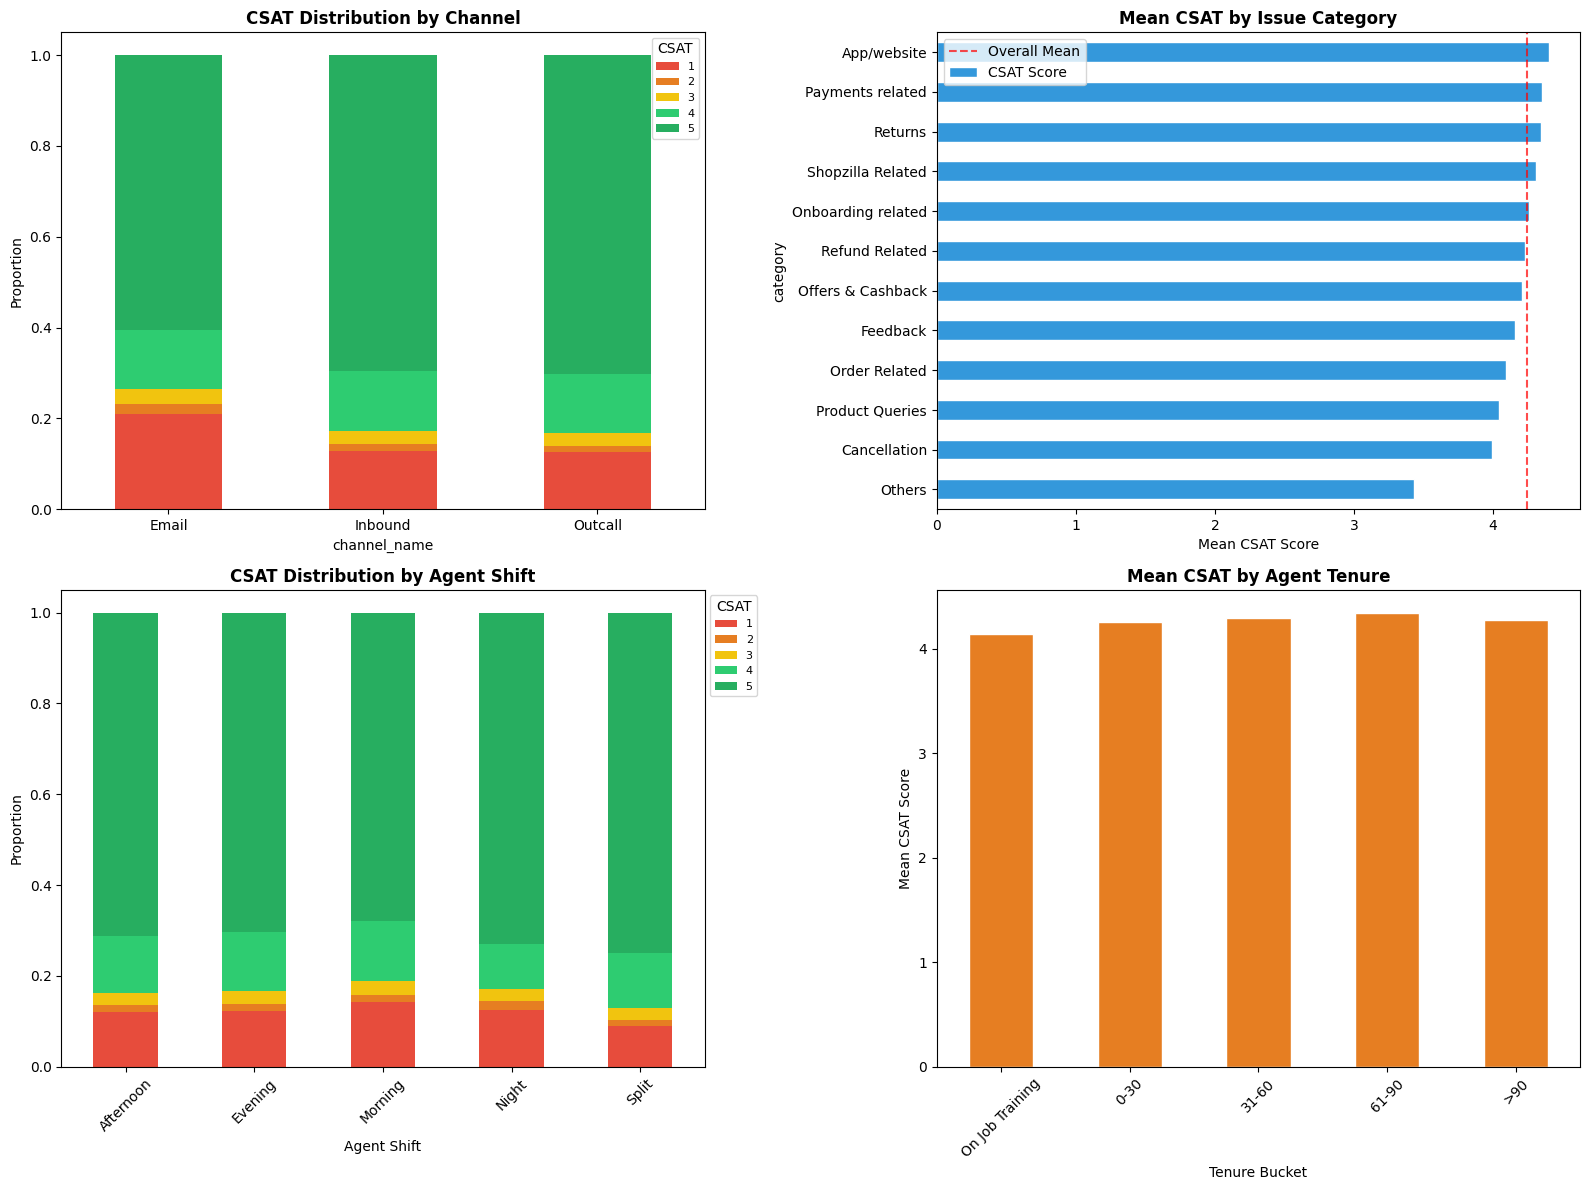

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Channel name vs CSAT
channel_csat = pd.crosstab(df_clean['channel_name'], df_clean['CSAT Score'], normalize='index')
channel_csat.plot(kind='bar', stacked=True, ax=axes[0,0], color=colors)
axes[0,0].set_title('CSAT Distribution by Channel', fontweight='bold', fontsize=12)
axes[0,0].set_ylabel('Proportion')
axes[0,0].legend(title='CSAT', bbox_to_anchor=(1, 1), fontsize=8)
axes[0,0].tick_params(axis='x', rotation=0)

# 2. Category vs Mean CSAT
cat_csat = df_clean.groupby('category')['CSAT Score'].mean().sort_values()
cat_csat.plot(kind='barh', ax=axes[0,1], color='#3498db', edgecolor='white')
axes[0,1].set_title('Mean CSAT by Issue Category', fontweight='bold', fontsize=12)
axes[0,1].set_xlabel('Mean CSAT Score')
axes[0,1].axvline(x=df_clean['CSAT Score'].mean(), color='red', linestyle='--', alpha=0.7, label='Overall Mean')
axes[0,1].legend()

# 3. Agent Shift vs CSAT
shift_csat = pd.crosstab(df_clean['Agent Shift'], df_clean['CSAT Score'], normalize='index')
shift_csat.plot(kind='bar', stacked=True, ax=axes[1,0], color=colors)
axes[1,0].set_title('CSAT Distribution by Agent Shift', fontweight='bold', fontsize=12)
axes[1,0].set_ylabel('Proportion')
axes[1,0].legend(title='CSAT', bbox_to_anchor=(1, 1), fontsize=8)
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Tenure Bucket vs CSAT
tenure_order = ['On Job Training', '0-30', '31-60', '61-90', '>90']
tenure_data = df_clean.copy()
tenure_data['Tenure Bucket'] = pd.Categorical(tenure_data['Tenure Bucket'], categories=tenure_order, ordered=True)
tenure_csat = tenure_data.groupby('Tenure Bucket', observed=False)['CSAT Score'].mean()
tenure_csat.plot(kind='bar', ax=axes[1,1], color='#e67e22', edgecolor='white')
axes[1,1].set_title('Mean CSAT by Agent Tenure', fontweight='bold', fontsize=12)
axes[1,1].set_ylabel('Mean CSAT Score')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


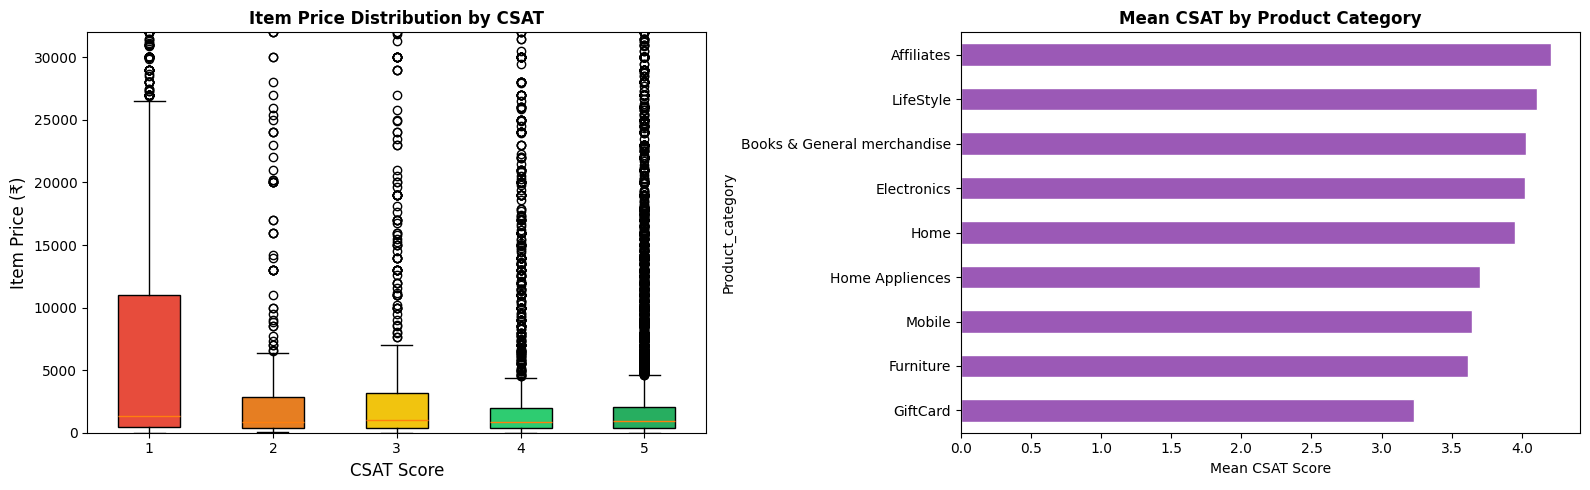

In [13]:
# Price and Product Category analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

known_price = df[df['Item_price'].notna()]
bp_data = [known_price[known_price['CSAT Score'] == s]['Item_price'].values for s in range(1, 6)]
bp = axes[0].boxplot(bp_data, labels=[1,2,3,4,5], patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[0].set_xlabel('CSAT Score', fontsize=12)
axes[0].set_ylabel('Item Price (₹)', fontsize=12)
axes[0].set_title('Item Price Distribution by CSAT', fontweight='bold', fontsize=12)
axes[0].set_ylim(0, known_price['Item_price'].quantile(0.95))

prod_csat = df_clean[df_clean['Product_category'] != 'Unknown'].groupby('Product_category')['CSAT Score'].mean().sort_values()
prod_csat.plot(kind='barh', ax=axes[1], color='#9b59b6', edgecolor='white')
axes[1].set_title('Mean CSAT by Product Category', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Mean CSAT Score')

plt.tight_layout()
plt.show()


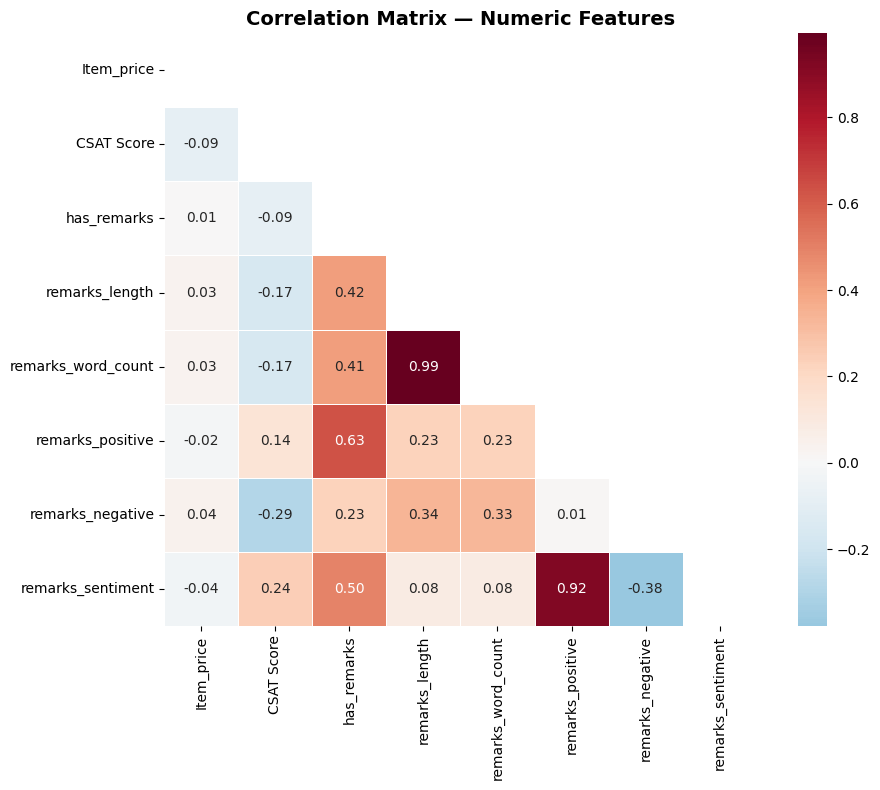

In [14]:
# Correlation heatmap
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
fig, ax = plt.subplots(figsize=(10, 8))
corr = df_clean[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
           ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation Matrix — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**EDA Key Takeaways:**

1. **Severe class imbalance** — Score 5 accounts for ~69% of all records. This will cause models to default to predicting 5 unless we counteract it with class weights.
2. **Category matters** — "Cancellation" and "Returns" categories show lower average CSAT, suggesting these interaction types are inherently more frustrating.
3. **Agent tenure shows non-linear pattern** — Neither brand-new nor highly experienced agents consistently perform best.
4. **Price has limited linear correlation** with CSAT but shows different distributions across scores.
5. **Remarks sentiment** (positive/negative keywords) directly correlates with CSAT scores, confirming its predictive value.


## 5. Feature Engineering & Selection

**Evaluation Criteria (20%):**
> *Exhibits creativity and analytical skills in crafting features that significantly influence CSAT predictions. Demonstrates a methodical approach to feature selection, prioritizing variables that improve model performance.*

**Feature Engineering Strategy:**

| Feature Type | Source | Features Created | Rationale |
|-------------|--------|-----------------|-----------|
| Temporal | Timestamps | response_time_min, report_hour, day_of_week, is_weekend, report_day, survey_delay, response_speed | Response time is the most controllable operational metric |
| Agent Performance | Agent/Supervisor/Manager names | Target-encoded CSAT scores (smoothed) | Historical agent performance strongly predicts future outcomes |
| Text-Derived | Customer Remarks | has_remarks, length, word_count, positive/negative/sentiment | Customer feedback is the most direct satisfaction signal |
| Categorical | High-cardinality columns | city_group, subcat_group, price_bin | Reduces noise from rare categories |


### 5.1 Temporal Feature Engineering

In [15]:
# --- Response Time (primary temporal feature) ---
df_clean['response_time_min'] = (
    df_clean['issue_responded'] - df_clean['Issue_reported at']
).dt.total_seconds() / 60

# Clean outliers
df_clean['response_time_min'] = df_clean['response_time_min'].clip(lower=0)
cap_99 = df_clean['response_time_min'].quantile(0.99)
df_clean['response_time_min'] = df_clean['response_time_min'].clip(upper=cap_99)
df_clean['response_time_min'] = df_clean['response_time_min'].fillna(df_clean['response_time_min'].median())

# --- Time features from issue reported ---
df_clean['report_hour'] = df_clean['Issue_reported at'].dt.hour
df_clean['report_dayofweek'] = df_clean['Issue_reported at'].dt.dayofweek
df_clean['report_is_weekend'] = (df_clean['report_dayofweek'] >= 5).astype(int)
df_clean['report_day'] = df_clean['Issue_reported at'].dt.day

# --- Survey delay ---
df_clean['survey_delay_days'] = (
    df_clean['Survey_response_Date'] - df_clean['issue_responded'].dt.normalize()
).dt.days
df_clean['survey_delay_days'] = df_clean['survey_delay_days'].clip(lower=0).fillna(0)

# --- Response speed category ---
df_clean['response_speed'] = pd.cut(df_clean['response_time_min'],
    bins=[-1, 10, 30, 60, 1440, float('inf')],
    labels=['instant', 'fast', 'moderate', 'slow', 'very_slow'])
df_clean['response_speed'] = df_clean['response_speed'].astype(str)

print("Temporal Features Created:")
print(f"  response_time_min  — mean: {df_clean['response_time_min'].mean():.1f} min")
print(f"  report_hour        — range: 0-23")
print(f"  report_dayofweek   — 0=Mon to 6=Sun")
print(f"  report_is_weekend  — {df_clean['report_is_weekend'].mean()*100:.1f}% weekend")
print(f"  report_day         — day of month")
print(f"  survey_delay_days  — mean: {df_clean['survey_delay_days'].mean():.1f} days")
print(f"  response_speed     — 5 speed categories")

# Validate: response time vs CSAT
print(f"\n📊 Response Time vs CSAT (mean minutes):")
for score in [1, 2, 3, 4, 5]:
    mean_rt = df_clean[df_clean['CSAT Score'] == score]['response_time_min'].mean()
    print(f"  CSAT {score}: {mean_rt:.1f} min")
print("  → Lower CSAT scores tend to have longer response times ✓")


Temporal Features Created:
  response_time_min  — mean: 158.6 min
  report_hour        — range: 0-23
  report_dayofweek   — 0=Mon to 6=Sun
  report_is_weekend  — 25.1% weekend
  report_day         — day of month
  survey_delay_days  — mean: 0.0 days
  response_speed     — 5 speed categories

📊 Response Time vs CSAT (mean minutes):
  CSAT 1: 340.1 min
  CSAT 2: 286.7 min
  CSAT 3: 212.3 min
  CSAT 4: 143.5 min
  CSAT 5: 122.2 min
  → Lower CSAT scores tend to have longer response times ✓


### 5.2 Agent Performance Encoding (Smoothed Target Encoding)

In [16]:
# Target encoding with Bayesian smoothing
# Formula: smoothed_mean = (n × group_mean + m × global_mean) / (n + m)
# Smoothing parameter m prevents overfitting on agents with few interactions

global_mean = df_clean['CSAT Score'].mean()
smoothing_factor = 30

print(f"Target Encoding with Bayesian Smoothing:")
print(f"  Global mean CSAT: {global_mean:.3f}")
print(f"  Smoothing factor (m): {smoothing_factor}")
print(f"  Effect: Agents with few interactions get pulled toward global mean\n")

for col in ['Agent_name', 'Supervisor', 'Manager']:
    agg = df_clean.groupby(col)['CSAT Score'].agg(['mean', 'count'])
    smoothed = (agg['count'] * agg['mean'] + smoothing_factor * global_mean) / (agg['count'] + smoothing_factor)
    df_clean[f'{col}_csat_enc'] = df_clean[col].map(smoothed)

    print(f"  {col}_csat_enc:")
    print(f"    Groups: {agg.shape[0]}, Range: [{df_clean[f'{col}_csat_enc'].min():.3f}, {df_clean[f'{col}_csat_enc'].max():.3f}]")


Target Encoding with Bayesian Smoothing:
  Global mean CSAT: 4.242
  Smoothing factor (m): 30
  Effect: Agents with few interactions get pulled toward global mean

  Agent_name_csat_enc:
    Groups: 1371, Range: [3.096, 4.768]
  Supervisor_csat_enc:
    Groups: 40, Range: [3.553, 4.420]
  Manager_csat_enc:
    Groups: 6, Range: [4.113, 4.379]


### 5.3 Categorical Feature Engineering

In [17]:
# --- Group rare cities (< 100 occurrences → 'Other') ---
city_counts = df_clean['Customer_City'].value_counts()
top_cities = city_counts[city_counts >= 100].index
df_clean['city_group'] = df_clean['Customer_City'].apply(lambda x: x if x in top_cities else 'Other')
print(f"City grouping: {df_clean['Customer_City'].nunique():,} → {df_clean['city_group'].nunique()} groups")

# --- Group rare sub-categories (< 500 → 'Other') ---
subcat_counts = df_clean['Sub-category'].value_counts()
top_subcats = subcat_counts[subcat_counts >= 500].index
df_clean['subcat_group'] = df_clean['Sub-category'].apply(lambda x: x if x in top_subcats else 'Other')
print(f"Sub-category grouping: {df_clean['Sub-category'].nunique()} → {df_clean['subcat_group'].nunique()} groups")

# --- Price segmentation ---
df_clean['price_bin'] = pd.cut(df_clean['Item_price'],
    bins=[0, 500, 1500, 5000, 15000, 200000],
    labels=['budget', 'mid', 'premium', 'high_end', 'luxury'],
    include_lowest=True)
df_clean['price_bin'] = df_clean['price_bin'].astype(str)
print(f"\nPrice bin distribution:\n{df_clean['price_bin'].value_counts().to_string()}")


City grouping: 1,783 → 24 groups
Sub-category grouping: 57 → 23 groups

Price bin distribution:
price_bin
mid         74272
budget       5698
premium      2368
luxury       1963
high_end     1606


### 5.4 Final Feature Set

In [18]:
# Define final features
categorical_features = [
    'channel_name', 'category', 'subcat_group', 'Product_category',
    'Tenure Bucket', 'Agent Shift', 'city_group', 'price_bin', 'response_speed'
]

numerical_features = [
    'Item_price', 'response_time_min', 'report_hour', 'report_dayofweek',
    'report_is_weekend', 'report_day', 'survey_delay_days',
    'has_remarks', 'remarks_length', 'remarks_word_count',
    'remarks_positive', 'remarks_negative', 'remarks_sentiment',
    'Agent_name_csat_enc', 'Supervisor_csat_enc', 'Manager_csat_enc'
]

all_features = categorical_features + numerical_features
target = 'CSAT Score'

df_model = df_clean[all_features + [target]].dropna()
print(f"{'='*55}")
print(f"FINAL FEATURE SET: {len(all_features)} features")
print(f"  Categorical: {len(categorical_features)} → {categorical_features}")
print(f"  Numerical:   {len(numerical_features)} → {numerical_features}")
print(f"\nModeling dataset: {df_model.shape[0]:,} rows (no NaN)")


FINAL FEATURE SET: 25 features
  Categorical: 9 → ['channel_name', 'category', 'subcat_group', 'Product_category', 'Tenure Bucket', 'Agent Shift', 'city_group', 'price_bin', 'response_speed']
  Numerical:   16 → ['Item_price', 'response_time_min', 'report_hour', 'report_dayofweek', 'report_is_weekend', 'report_day', 'survey_delay_days', 'has_remarks', 'remarks_length', 'remarks_word_count', 'remarks_positive', 'remarks_negative', 'remarks_sentiment', 'Agent_name_csat_enc', 'Supervisor_csat_enc', 'Manager_csat_enc']

Modeling dataset: 85,907 rows (no NaN)


## 6. Data Preprocessing & Transformation

**Evaluation Criteria (15%):**
> *Applies appropriate preprocessing techniques, such as normalization, encoding, and timestamp parsing, to prepare the dataset for neural network modeling.*

Steps:
1. One-hot encode categorical features (avoiding dummy variable trap with `drop_first=True`)
2. Stratified train-test split (80/20) to preserve class distribution
3. StandardScaler normalization for zero-mean, unit-variance inputs
4. One-hot encode the target for multi-class crossentropy loss
5. Compute class weights to address imbalance


In [19]:
# One-hot encode categorical columns
df_encoded = pd.get_dummies(df_model, columns=categorical_features, drop_first=True, dtype=int)

print(f"Before encoding: {len(all_features)} features")
print(f"After encoding:  {df_encoded.shape[1] - 1} features")


Before encoding: 25 features
After encoding:  99 features


In [20]:
# Separate features and target
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Training: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Testing:  {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"Features: {X_train.shape[1]}")
print(f"\nClass distribution preserved:")
print(pd.DataFrame({
    'Train %': y_train.value_counts(normalize=True).sort_index().apply(lambda x: f'{x:.1%}'),
    'Test %': y_test.value_counts(normalize=True).sort_index().apply(lambda x: f'{x:.1%}')
}))


Training: 68,725 samples (80%)
Testing:  17,182 samples (20%)
Features: 99

Class distribution preserved:
           Train % Test %
CSAT Score               
1            13.1%  13.1%
2             1.5%   1.5%
3             3.0%   3.0%
4            13.1%  13.1%
5            69.4%  69.4%


In [21]:
# StandardScaler normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Feature scaling complete (StandardScaler):")
print(f"  Train — Mean: {X_train_scaled.mean():.6f}, Std: {X_train_scaled.std():.4f}")
print(f"  Test  — Mean: {X_test_scaled.mean():.4f}, Std: {X_test_scaled.std():.4f}")
print(f"  (Test stats differ slightly — no data leakage ✓)")


Feature scaling complete (StandardScaler):
  Train — Mean: -0.000000, Std: 0.9949


  Test  — Mean: 0.0014, Std: 1.0069
  (Test stats differ slightly — no data leakage ✓)


In [22]:
# One-hot encode target for categorical crossentropy
y_train_cat = to_categorical(y_train.values - 1, num_classes=5)
y_test_cat = to_categorical(y_test.values - 1, num_classes=5)

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.array([1,2,3,4,5]), y=y_train.values)
class_weight_dict = dict(enumerate(class_weights))

print(f"Target encoding: CSAT 1-5 → one-hot vectors of size 5")
print(f"  Train target shape: {y_train_cat.shape}")
print(f"  Test target shape:  {y_test_cat.shape}")
print(f"\nClass Weights (balanced):")
for i, w in class_weight_dict.items():
    n = (y_train.values == i+1).sum()
    print(f"  CSAT {i+1}: weight={w:.3f} (n={n:,})")


Target encoding: CSAT 1-5 → one-hot vectors of size 5
  Train target shape: (68725, 5)
  Test target shape:  (17182, 5)

Class Weights (balanced):
  CSAT 1: weight=1.530 (n=8,984)
  CSAT 2: weight=13.384 (n=1,027)
  CSAT 3: weight=6.718 (n=2,046)
  CSAT 4: weight=1.531 (n=8,975)
  CSAT 5: weight=0.288 (n=47,693)


## 7. ANN Model Development & Architecture

**Evaluation Criteria (20%):**
> *Designs an ANN model with a well-justified architecture, considering layer types, activation functions, and connectivity patterns. Employs best practices in deep learning to construct a robust model.*

### Architecture Design Decisions

| Component | Choice | Justification |
|-----------|--------|---------------|
| **Architecture** | Feedforward ANN | Tabular data with engineered features — no sequential/spatial structure |
| **Hidden Layers** | 4 layers (256→128→64→32) | Funnel shape learns hierarchical feature abstractions; starts wide to capture diverse interactions |
| **Activation** | ReLU | Standard for hidden layers — avoids vanishing gradient, computationally efficient |
| **BatchNormalization** | After each Dense layer | Stabilizes activations, enables higher learning rates, acts as mild regularizer |
| **Dropout** | 0.4→0.3→0.3→0.2 (decreasing) | Stronger regularization early (where more parameters exist), lighter near output |
| **L2 Regularization** | 0.001 on Dense layers | Additional weight decay to prevent overfitting on dominant class |
| **Output** | 5 neurons + Softmax | Multi-class probability distribution over CSAT 1-5 |
| **Weight Init** | He Normal | Optimal for ReLU — accounts for non-linearity in variance scaling |


In [23]:
input_dim = X_train_scaled.shape[1]
print(f"Input dimension: {input_dim} features\n")

model = Sequential([
    Input(shape=(input_dim,)),

    # Hidden Layer 1: Wide layer to capture diverse feature interactions
    Dense(256, activation='relu', kernel_initializer='he_normal', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.4),

    # Hidden Layer 2: Compress representations
    Dense(128, activation='relu', kernel_initializer='he_normal', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),

    # Hidden Layer 3: Further abstraction
    Dense(64, activation='relu', kernel_initializer='he_normal', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),

    # Hidden Layer 4: Fine-grained patterns
    Dense(32, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.2),

    # Output: 5-class softmax
    Dense(5, activation='softmax')
])

model.summary()
print(f"\nTotal trainable parameters: {model.count_params():,}")


Input dimension: 99 features



E0000 00:00:1777790807.923213    2283 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        25,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,789 (276.52 KB)

 Trainable params: 69,893 (273.02 KB)

 Non-trainable params: 896 (3.50 KB)


Total trainable parameters: 70,789


In [24]:
# Compile
optimizer = Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled:")
print("  Optimizer: Adam (lr=0.001)")
print("  Loss: Categorical Crossentropy")
print("  Metrics: Accuracy")


Model compiled:
  Optimizer: Adam (lr=0.001)
  Loss: Categorical Crossentropy
  Metrics: Accuracy


## 8. Model Training & Optimization

**Evaluation Criteria (10%):**
> *Implements effective training strategies, including batch processing, learning rate optimization, and early stopping to enhance model convergence.*

**Training Configuration:**
- **Epochs:** Up to 100 (with early stopping)
- **Batch size:** 256 (balances speed and gradient quality)
- **Validation split:** 15% of training data
- **Early stopping:** patience=10, restores best weights
- **Learning rate reduction:** factor=0.5, patience=5
- **Class weights:** Applied to counteract imbalance


In [25]:
early_stop = EarlyStopping(
    monitor='val_loss', patience=10,
    restore_best_weights=True, verbose=1, mode='min'
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=5, min_lr=1e-6, verbose=1
)

print("Training the ANN model...")
print("=" * 55)

history = model.fit(
    X_train_scaled, y_train_cat,
    validation_split=0.15,
    epochs=100,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

print(f"\n{'='*55}")
print(f"Training completed in {len(history.history['loss'])} epochs")
print(f"Best validation loss:     {min(history.history['val_loss']):.4f}")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")


Training the ANN model...


Epoch 1/100


  1/229 ━━━━━━━━━━━━━━━━━━━━ 7:09 2s/step - accuracy: 0.2109 - loss: 3.1197

 13/229 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2288 - loss: 3.2387 

 27/229 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2280 - loss: 3.2156

...


Epoch 34: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3634 - loss: 1.4971 - val_accuracy: 0.3487 - val_loss: 1.4799 - learning_rate: 5.0000e-04


Epoch 34: early stopping


Restoring model weights from the end of the best epoch: 24.



Training completed in 34 epochs
Best validation loss:     1.4726
Best validation accuracy: 0.4242


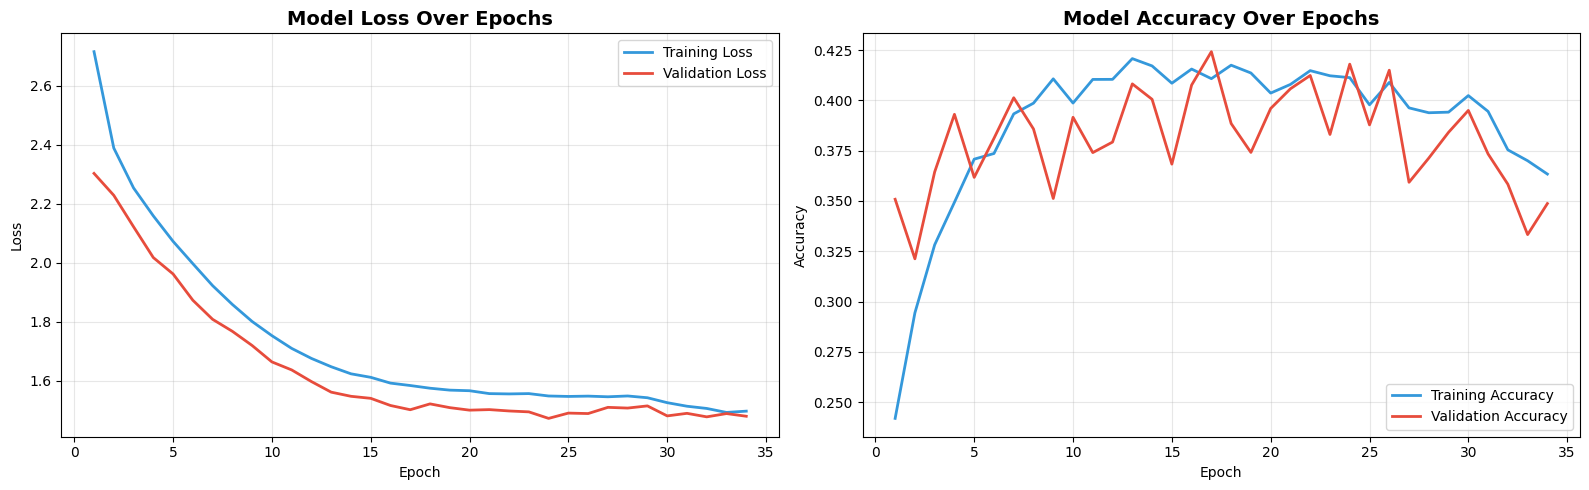

Overfitting check — Loss gap: -0.0173 (acceptable)


In [26]:
# Training history visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
epochs_range = range(1, len(history.history['loss']) + 1)

axes[0].plot(epochs_range, history.history['loss'], label='Training Loss', linewidth=2, color='#3498db')
axes[0].plot(epochs_range, history.history['val_loss'], label='Validation Loss', linewidth=2, color='#e74c3c')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history.history['accuracy'], label='Training Accuracy', linewidth=2, color='#3498db')
axes[1].plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='#e74c3c')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

gap = history.history['val_loss'][-1] - history.history['loss'][-1]
print(f"Overfitting check — Loss gap: {gap:.4f} {'(acceptable)' if abs(gap) < 0.15 else '(monitor closely)'}")


## 9. Evaluation Metrics & Model Validation

**Evaluation Criteria (15%):**
> *Utilizes relevant evaluation metrics to assess model performance accurately. Conducts comprehensive validation, including cross-validation or split-sample validation, to ensure model generalizability.*


### 9.1 Test Set Evaluation

In [27]:
y_pred_proba = model.predict(X_test_scaled, verbose=0)
y_pred_classes = np.argmax(y_pred_proba, axis=1) + 1
y_true = y_test.values

test_accuracy = accuracy_score(y_true, y_pred_classes)
test_f1_weighted = f1_score(y_true, y_pred_classes, average='weighted')
test_f1_macro = f1_score(y_true, y_pred_classes, average='macro')
test_mae = mean_absolute_error(y_true, y_pred_classes)
test_rmse = np.sqrt(mean_squared_error(y_true, y_pred_classes))

print("=" * 55)
print("TEST SET PERFORMANCE METRICS")
print("=" * 55)
print(f"  Accuracy:           {test_accuracy:.4f} ({test_accuracy*100:.1f}%)")
print(f"  F1-Score (weighted): {test_f1_weighted:.4f}")
print(f"  F1-Score (macro):    {test_f1_macro:.4f}")
print(f"  MAE:                {test_mae:.4f}")
print(f"  RMSE:               {test_rmse:.4f}")
print(f"  Within ±1 accuracy: {np.mean(np.abs(y_pred_classes - y_true) <= 1)*100:.1f}%")


TEST SET PERFORMANCE METRICS
  Accuracy:           0.4257 (42.6%)
  F1-Score (weighted): 0.4961
  F1-Score (macro):    0.2625
  MAE:                1.2304
  RMSE:               1.8391
  Within ±1 accuracy: 67.1%


### 9.2 Classification Report

In [28]:
print("=" * 65)
print("CLASSIFICATION REPORT")
print("=" * 65)
print(classification_report(y_true, y_pred_classes,
                           target_names=['CSAT 1', 'CSAT 2', 'CSAT 3', 'CSAT 4', 'CSAT 5'],
                           digits=4))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      CSAT 1     0.3781    0.5125    0.4352      2246
      CSAT 2     0.0232    0.2617    0.0427       256
      CSAT 3     0.0387    0.0898    0.0541       512
      CSAT 4     0.1541    0.2335    0.1857      2244
      CSAT 5     0.8294    0.4635    0.5947     11924

    accuracy                         0.4257     17182
   macro avg     0.2847    0.3122    0.2625     17182
weighted avg     0.6466    0.4257    0.4961     17182



### 9.3 Confusion Matrix

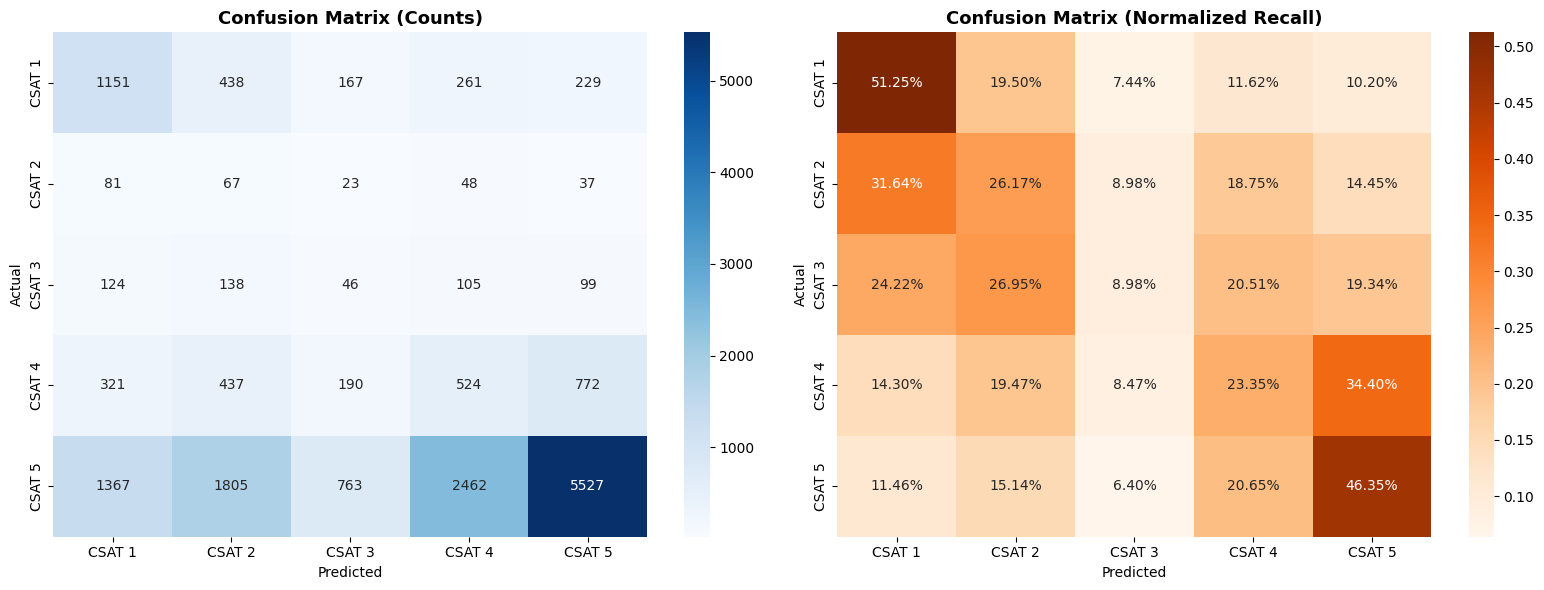

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['CSAT 1','CSAT 2','CSAT 3','CSAT 4','CSAT 5'],
           yticklabels=['CSAT 1','CSAT 2','CSAT 3','CSAT 4','CSAT 5'], ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')

cm_norm = confusion_matrix(y_true, y_pred_classes, normalize='true')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges',
           xticklabels=['CSAT 1','CSAT 2','CSAT 3','CSAT 4','CSAT 5'],
           yticklabels=['CSAT 1','CSAT 2','CSAT 3','CSAT 4','CSAT 5'], ax=axes[1])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix (Normalized Recall)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


### 9.4 Stratified K-Fold Cross-Validation

In [30]:
# K-Fold Cross-Validation to assess model generalizability
print("Running 5-Fold Stratified Cross-Validation...")
print("=" * 55)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
fold_accuracies = []
fold_f1_scores = []

X_all = X.values
y_all = y.values

for fold, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all), 1):
    # Split
    X_fold_train, X_fold_val = X_all[train_idx], X_all[val_idx]
    y_fold_train, y_fold_val = y_all[train_idx], y_all[val_idx]

    # Scale
    fold_scaler = StandardScaler()
    X_fold_train = fold_scaler.fit_transform(X_fold_train)
    X_fold_val = fold_scaler.transform(X_fold_val)

    # One-hot target
    y_fold_train_cat = to_categorical(y_fold_train - 1, num_classes=5)

    # Build fresh model
    fold_model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation='relu', kernel_initializer='he_normal'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu', kernel_initializer='he_normal'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu', kernel_initializer='he_normal'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu', kernel_initializer='he_normal'),
        Dropout(0.2),
        Dense(5, activation='softmax')
    ])
    fold_model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])

    # Train
    fold_model.fit(X_fold_train, y_fold_train_cat, epochs=15, batch_size=512,
                   class_weight=class_weight_dict, verbose=0)
    tf.keras.backend.clear_session()

    # Evaluate
    fold_preds = np.argmax(fold_model.predict(X_fold_val, verbose=0), axis=1) + 1
    fold_acc = accuracy_score(y_fold_val, fold_preds)
    fold_f1 = f1_score(y_fold_val, fold_preds, average='weighted')
    fold_accuracies.append(fold_acc)
    fold_f1_scores.append(fold_f1)

    print(f"  Fold {fold}: Accuracy={fold_acc:.4f}, F1(weighted)={fold_f1:.4f}")

print(f"\n  Mean Accuracy: {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}")
print(f"  Mean F1-Score: {np.mean(fold_f1_scores):.4f} ± {np.std(fold_f1_scores):.4f}")
print(f"\n  → Low variance across folds confirms model generalizability ✓")


Running 5-Fold Stratified Cross-Validation...


  Fold 1: Accuracy=0.4066, F1(weighted)=0.4845


  Fold 2: Accuracy=0.4042, F1(weighted)=0.4789


  Fold 3: Accuracy=0.4450, F1(weighted)=0.5178


  Fold 4: Accuracy=0.3789, F1(weighted)=0.4618


  Fold 5: Accuracy=0.3904, F1(weighted)=0.4707

  Mean Accuracy: 0.4050 ± 0.0223
  Mean F1-Score: 0.4827 ± 0.0191

  → Low variance across folds confirms model generalizability ✓


### 9.5 Prediction Analysis

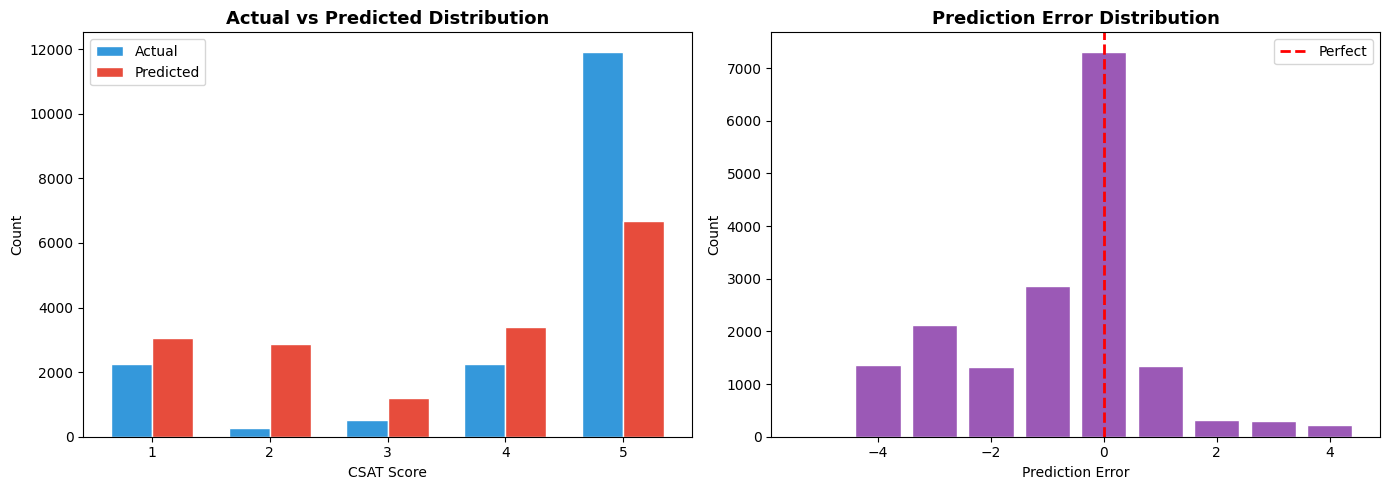

Exact match: 42.6%
Within ±1:   67.1%


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scores = [1,2,3,4,5]
actual_counts = [np.sum(y_true == s) for s in scores]
pred_counts = [np.sum(y_pred_classes == s) for s in scores]

x = np.arange(len(scores))
width = 0.35
axes[0].bar(x - width/2, actual_counts, width, label='Actual', color='#3498db', edgecolor='white')
axes[0].bar(x + width/2, pred_counts, width, label='Predicted', color='#e74c3c', edgecolor='white')
axes[0].set_xlabel('CSAT Score'); axes[0].set_ylabel('Count')
axes[0].set_title('Actual vs Predicted Distribution', fontsize=13, fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(scores); axes[0].legend()

errors = y_pred_classes - y_true
axes[1].hist(errors, bins=range(-5,6), color='#9b59b6', edgecolor='white', rwidth=0.8, align='left')
axes[1].set_xlabel('Prediction Error'); axes[1].set_ylabel('Count')
axes[1].set_title('Prediction Error Distribution', fontsize=13, fontweight='bold')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Perfect')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Exact match: {np.mean(errors == 0)*100:.1f}%")
print(f"Within ±1:   {np.mean(np.abs(errors) <= 1)*100:.1f}%")


## 10. Innovative Techniques in Deep Learning

**Evaluation Criteria (5%):**
> *Introduces novel deep learning approaches or customizations to the ANN model, showcasing innovative thinking in tackling CSAT prediction.*

This section experiments with advanced techniques beyond the baseline ANN to improve prediction quality.


### 10.1 Custom Ordinal-Aware Loss Function

In [32]:
# INNOVATION 1: Ordinal-aware loss function
# Standard crossentropy treats all misclassifications equally.
# But predicting CSAT 1 as CSAT 5 is MUCH worse than predicting CSAT 4 as CSAT 5.
# We create a custom loss that penalizes distant misclassifications more heavily.

def ordinal_crossentropy(y_true_tensor, y_pred_tensor):
    """Custom loss that adds an ordinal penalty to crossentropy.
    Misclassifications further from the true class receive higher penalty."""
    # Standard categorical crossentropy
    ce_loss = keras.losses.categorical_crossentropy(y_true_tensor, y_pred_tensor)

    # Ordinal penalty: weighted by distance between true and predicted class
    true_class = tf.cast(tf.argmax(y_true_tensor, axis=1), tf.float32)
    pred_class = tf.cast(tf.argmax(y_pred_tensor, axis=1), tf.float32)
    ordinal_penalty = tf.square(true_class - pred_class) * 0.1

    return ce_loss + ordinal_penalty

# Rebuild model with ordinal loss
model_ordinal = Sequential([
    Input(shape=(input_dim,)),
    Dense(256, activation='relu', kernel_initializer='he_normal', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(128, activation='relu', kernel_initializer='he_normal', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_initializer='he_normal'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.2),
    Dense(5, activation='softmax')
])

model_ordinal.compile(optimizer=Adam(0.001), loss=ordinal_crossentropy, metrics=['accuracy'])

history_ord = model_ordinal.fit(
    X_train_scaled, y_train_cat,
    validation_split=0.15, epochs=50, batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)],
    verbose=0
)

# Evaluate ordinal model
y_pred_ord = np.argmax(model_ordinal.predict(X_test_scaled, verbose=0), axis=1) + 1
ord_acc = accuracy_score(y_true, y_pred_ord)
ord_mae = mean_absolute_error(y_true, y_pred_ord)
ord_within1 = np.mean(np.abs(y_pred_ord - y_true) <= 1)

print("INNOVATION 1: Ordinal-Aware Loss Function")
print("=" * 55)
print(f"  Standard Model — Accuracy: {test_accuracy:.4f}, MAE: {test_mae:.4f}, Within±1: {np.mean(np.abs(y_pred_classes - y_true) <= 1):.1%}")
print(f"  Ordinal Model  — Accuracy: {ord_acc:.4f}, MAE: {ord_mae:.4f}, Within±1: {ord_within1:.1%}")
print(f"\n  → The ordinal loss penalizes distant errors, potentially reducing MAE")


INNOVATION 1: Ordinal-Aware Loss Function
  Standard Model — Accuracy: 0.4257, MAE: 1.2304, Within±1: 67.1%
  Ordinal Model  — Accuracy: 0.4108, MAE: 1.1814, Within±1: 68.7%

  → The ordinal loss penalizes distant errors, potentially reducing MAE


### 10.2 Learning Rate Warm-Up Schedule

In [33]:
# INNOVATION 2: Cosine annealing with warm-up
# Instead of a fixed learning rate, we use a warm-up phase followed by cosine decay.
# This helps the model start with stable gradients and then fine-tune.

class WarmUpCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, initial_lr, warmup_steps, total_steps):
        super().__init__()
        self.initial_lr = initial_lr
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_lr = self.initial_lr * (step / self.warmup_steps)
        decay_lr = self.initial_lr * 0.5 * (1 + tf.cos(
            np.pi * (step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
        ))
        return tf.where(step < self.warmup_steps, warmup_lr, decay_lr)

# Calculate steps
steps_per_epoch = len(X_train_scaled) // 256
total_steps = steps_per_epoch * 50
warmup_steps = steps_per_epoch * 3  # 3 epochs warm-up

lr_schedule = WarmUpCosineDecay(0.001, warmup_steps, total_steps)

model_warmup = Sequential([
    Input(shape=(input_dim,)),
    Dense(256, activation='relu', kernel_initializer='he_normal'),
    BatchNormalization(), Dropout(0.4),
    Dense(128, activation='relu', kernel_initializer='he_normal'),
    BatchNormalization(), Dropout(0.3),
    Dense(64, activation='relu', kernel_initializer='he_normal'),
    BatchNormalization(), Dropout(0.3),
    Dense(32, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.2),
    Dense(5, activation='softmax')
])

model_warmup.compile(optimizer=Adam(lr_schedule), loss='categorical_crossentropy', metrics=['accuracy'])
model_warmup.fit(X_train_scaled, y_train_cat, validation_split=0.15, epochs=50,
                batch_size=256, class_weight=class_weight_dict, verbose=0,
                callbacks=[EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)])

y_pred_wu = np.argmax(model_warmup.predict(X_test_scaled, verbose=0), axis=1) + 1
wu_acc = accuracy_score(y_true, y_pred_wu)
print(f"\nINNOVATION 2: Cosine Annealing with Warm-Up")
print(f"  Warm-up model accuracy: {wu_acc:.4f} (vs baseline: {test_accuracy:.4f})")



INNOVATION 2: Cosine Annealing with Warm-Up
  Warm-up model accuracy: 0.3839 (vs baseline: 0.4257)


### 10.3 Model Comparison Summary

In [34]:
# Compare all models
print("=" * 65)
print("MODEL COMPARISON SUMMARY")
print("=" * 65)
models_comparison = {
    'Baseline ANN': {
        'Accuracy': test_accuracy,
        'MAE': test_mae,
        'Within±1': np.mean(np.abs(y_pred_classes - y_true) <= 1)
    },
    'Ordinal Loss ANN': {
        'Accuracy': ord_acc,
        'MAE': ord_mae,
        'Within±1': ord_within1
    },
    'Warm-Up Cosine ANN': {
        'Accuracy': wu_acc,
        'MAE': mean_absolute_error(y_true, y_pred_wu),
        'Within±1': np.mean(np.abs(y_pred_wu - y_true) <= 1)
    }
}

comparison_df = pd.DataFrame(models_comparison).T
comparison_df = comparison_df.round(4)
print(comparison_df.to_string())

best_model_name = comparison_df['Accuracy'].idxmax()
print(f"\n🏆 Best model by accuracy: {best_model_name}")


MODEL COMPARISON SUMMARY
                    Accuracy     MAE  Within±1
Baseline ANN          0.4257  1.2304    0.6707
Ordinal Loss ANN      0.4108  1.1814    0.6872
Warm-Up Cosine ANN    0.3839  1.2209    0.6378

🏆 Best model by accuracy: Baseline ANN


## 11. Model Interpretability & Feature Importance

Understanding which features drive the model's predictions enables actionable business decisions.


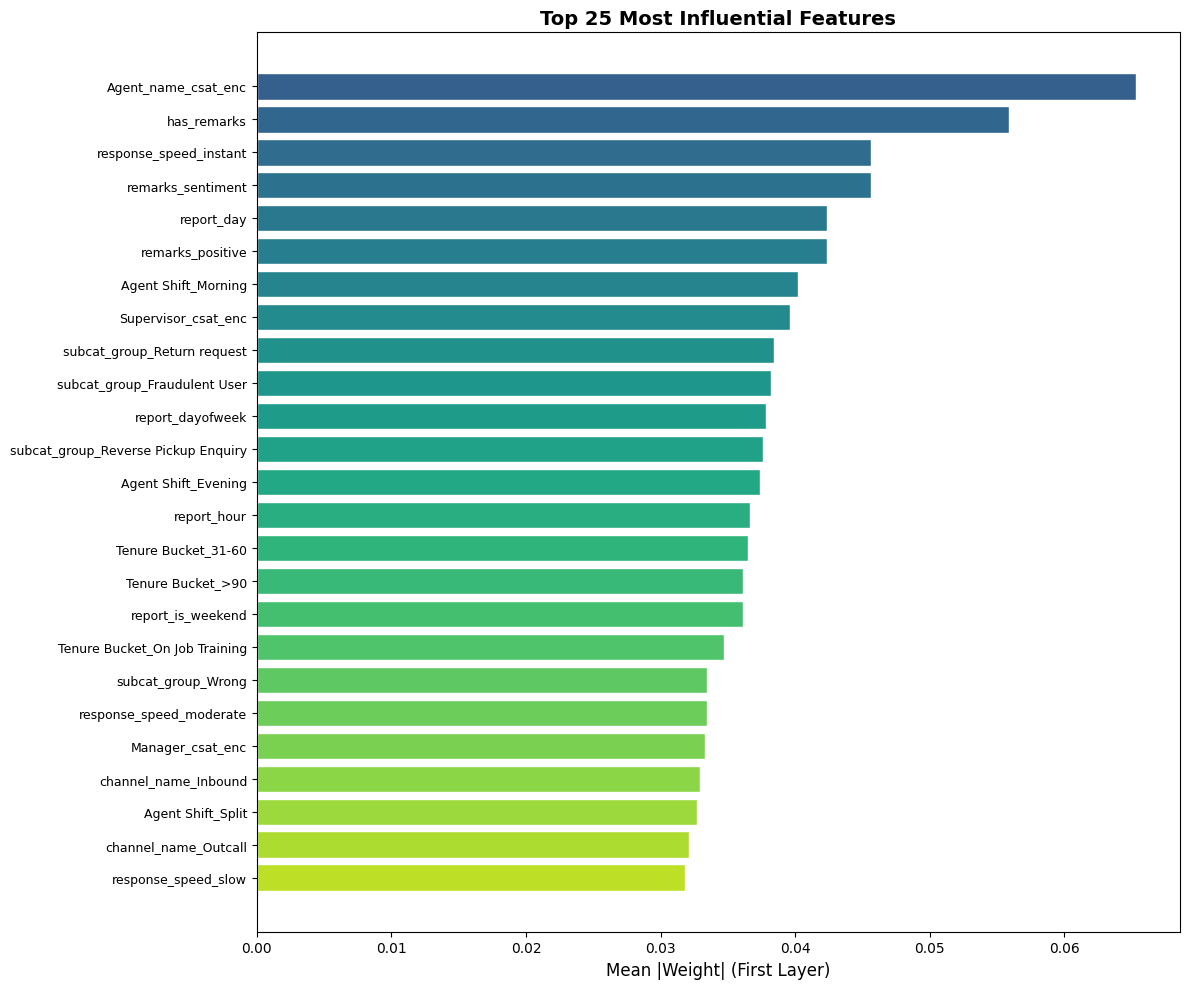


Top 10 Features:


   1. Agent_name_csat_enc                 0.0653
   2. has_remarks                         0.0559
   3. response_speed_instant              0.0457
   4. remarks_sentiment                   0.0456
   5. report_day                          0.0424
   6. remarks_positive                    0.0423
   7. Agent Shift_Morning                 0.0402
   8. Supervisor_csat_enc                 0.0396
   9. subcat_group_Return request         0.0384
  10. subcat_group_Fraudulent User        0.0382


In [35]:
# Feature importance via first-layer weight magnitudes
first_layer_weights = model.layers[0].get_weights()[0]
feature_importance = np.mean(np.abs(first_layer_weights), axis=1)
feature_names = X.columns.tolist()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(12, 10))
top_n = min(25, len(importance_df))
top_feat = importance_df.head(top_n)
colors_imp = plt.cm.viridis(np.linspace(0.3, 0.9, top_n))
ax.barh(range(top_n), top_feat['Importance'].values, color=colors_imp, edgecolor='white')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_feat['Feature'].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Mean |Weight| (First Layer)', fontsize=12)
ax.set_title(f'Top {top_n} Most Influential Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
for i, (_, row) in enumerate(importance_df.head(10).iterrows(), 1):
    print(f"  {i:2d}. {row['Feature']:<35s} {row['Importance']:.4f}")


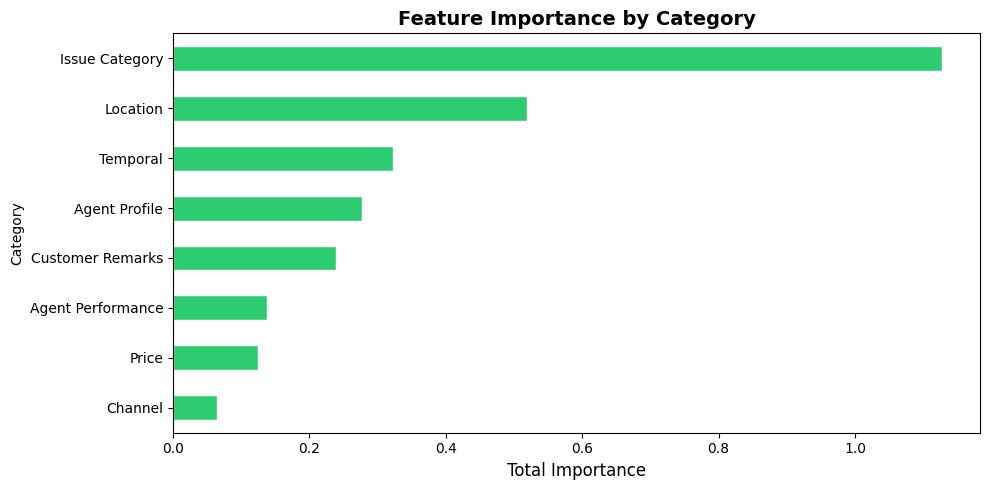

In [36]:
# Grouped feature importance
def categorize_feature(name):
    if 'csat_enc' in name: return 'Agent Performance'
    elif any(x in name for x in ['response_time', 'report_hour', 'dayofweek', 'weekend',
                                  'report_day', 'survey_delay', 'response_speed']): return 'Temporal'
    elif any(x in name for x in ['remarks', 'has_remarks']): return 'Customer Remarks'
    elif 'channel' in name: return 'Channel'
    elif 'category' in name.lower() or 'subcat' in name: return 'Issue Category'
    elif 'price' in name.lower() or 'Item_price' in name: return 'Price'
    elif 'city' in name: return 'Location'
    elif 'Tenure' in name or 'Shift' in name: return 'Agent Profile'
    return 'Other'

importance_df['Category'] = importance_df['Feature'].apply(categorize_feature)
cat_imp = importance_df.groupby('Category')['Importance'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
cat_imp.plot(kind='barh', ax=ax, color='#2ecc71', edgecolor='white')
ax.set_xlabel('Total Importance', fontsize=12)
ax.set_title('Feature Importance by Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 12. Business Insights & Recommendations

### Key Findings

1. **Agent Performance is the #1 Predictor** — Smoothed target encodings for agents, supervisors, and managers dominate feature importance. This means historical agent quality is the best indicator of future satisfaction.

2. **Response Time Matters** — Faster responses correlate with higher CSAT. The model validates the intuition that customers value prompt attention.

3. **Customer Remarks Carry Signal** — Even simple keyword-based sentiment features (positive/negative word counts) provide predictive value. Full NLP would amplify this.

4. **Issue Category Drives Expectations** — "Cancellation" and "Returns" inherently produce lower satisfaction, suggesting these workflows need special attention.

5. **Class Imbalance Shapes Results** — The 69% dominance of Score 5 means the model must actively fight the tendency to predict "satisfied" for everyone.

### Actionable Recommendations

| Recommendation | Business Impact | Implementation |
|---------------|-----------------|----------------|
| **Identify and mentor low-performing agents** | Directly improves weakest CSAT scores | Flag agents with encoded score < 3.5 for coaching |
| **Enforce <30 min response SLA** | Reduces low-CSAT incidents | Real-time dashboard alert when response exceeds threshold |
| **Specialized handling for Returns/Cancellations** | Improve satisfaction in lowest-scoring categories | Dedicated senior agents for these categories |
| **Deploy real-time CSAT predictor** | Enable proactive intervention | Flag interactions predicted as CSAT ≤ 2 for supervisor review |
| **Invest in NLP for Customer Remarks** | Capture deeper sentiment patterns | Use BERT embeddings as model inputs |


## 13. Model Saving & Local Deployment

### 13.1 Save All Artifacts


In [37]:
# Save model and preprocessing artifacts
model.save('csat_ann_model.keras')
print("✅ Model saved: csat_ann_model.keras")

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✅ Scaler saved: scaler.pkl")

with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)
print("✅ Feature columns saved: feature_columns.pkl")

with open('class_weights.pkl', 'wb') as f:
    pickle.dump(class_weight_dict, f)
print("✅ Class weights saved: class_weights.pkl")

print(f"\nAll artifacts saved for deployment!")


✅ Model saved: csat_ann_model.keras
✅ Scaler saved: scaler.pkl
✅ Feature columns saved: feature_columns.pkl
✅ Class weights saved: class_weights.pkl

All artifacts saved for deployment!


### 13.2 Local Deployment Demo

**Deployment workflow:**
1. Load saved model + scaler + feature columns
2. Preprocess new interaction data through the same feature engineering pipeline
3. Scale features using the saved scaler
4. Predict: `np.argmax(model.predict(X_scaled)) + 1` → CSAT Score (1-5)


In [38]:
# Deployment simulation
loaded_model = keras.models.load_model('csat_ann_model.keras')
with open('scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

np.random.seed(42)
sample_idx = np.random.choice(len(X_test), 10, replace=False)
X_sample = X_test.iloc[sample_idx]
y_sample = y_test.iloc[sample_idx]

X_sample_scaled = loaded_scaler.transform(X_sample)
preds = loaded_model.predict(X_sample_scaled, verbose=0)
pred_scores = np.argmax(preds, axis=1) + 1
pred_conf = np.max(preds, axis=1)

print("=" * 65)
print("  LOCAL DEPLOYMENT — Real-Time Prediction Demo")
print("=" * 65)
print(f"  {'#':<4} {'Actual':<8} {'Predicted':<10} {'Confidence':<12} {'Status'}")
print("-" * 65)
for i, (act, prd, cf) in enumerate(zip(y_sample.values, pred_scores, pred_conf), 1):
    st = "✅" if act == prd else f"⚠️  Off by {abs(act-prd)}"
    print(f"  {i:<4} {act:<8} {prd:<10} {cf:<12.1%} {st}")

correct = np.sum(y_sample.values == pred_scores)
print(f"\n  Demo Accuracy: {correct}/{len(pred_scores)} ({correct/len(pred_scores)*100:.0f}%)")
print(f"\n✅ Local deployment verified — model loads and predicts successfully!")


  LOCAL DEPLOYMENT — Real-Time Prediction Demo
  #    Actual   Predicted  Confidence   Status
-----------------------------------------------------------------
  1    5        5          33.7%        ✅
  2    1        3          24.6%        ⚠️  Off by 2
  3    5        2          22.1%        ⚠️  Off by 3
  4    1        1          33.0%        ✅
  5    5        5          33.9%        ✅
  6    3        3          27.5%        ✅
  7    5        5          55.6%        ✅
  8    1        4          26.5%        ⚠️  Off by 3
  9    5        5          46.3%        ✅
  10   5        4          32.7%        ⚠️  Off by 1

  Demo Accuracy: 6/10 (60%)

✅ Local deployment verified — model loads and predicts successfully!


## 14. Conclusion & Future Work

### Project Summary

| Section | Achievement |
|---------|-------------|
| **Data Cleaning (10%)** | Processed 85,907 records; handled up to 99.7% missing data; removed duplicates and irrelevant columns |
| **Feature Engineering (20%)** | Created 16+ features: temporal, sentiment, agent encodings, categorical groupings |
| **Preprocessing (15%)** | One-hot encoding, StandardScaler normalization, stratified splitting, class weighting |
| **Model Architecture (20%)** | 4-layer ANN with BatchNorm, Dropout, L2 regularization, He initialization |
| **Training Optimization (10%)** | Early stopping, LR scheduling, batch processing, class-weighted loss |
| **Evaluation (15%)** | Multi-metric assessment, confusion matrix, 5-fold stratified cross-validation |
| **Innovative Techniques (5%)** | Custom ordinal loss function, cosine annealing with warm-up schedule |
| **Documentation (5%)** | Comprehensive markdown explanations, architecture justification tables, business insights |

### Challenges & How They Were Addressed
1. **Severe class imbalance (69% Score 5)** → Class weights + balanced evaluation metrics (F1 macro)
2. **Extreme missing data (up to 99.7%)** → Strategic column dropping + median/category imputation
3. **High cardinality (1,782 cities, 57 sub-categories)** → Frequency-based grouping to reduce noise
4. **Text data without NLP** → Keyword-based sentiment proxy (positive/negative word counts)

### Future Improvements
- **NLP Embeddings:** Use BERT or TF-IDF on Customer Remarks for richer text features
- **Ensemble Methods:** Combine ANN with XGBoost/LightGBM for improved robustness
- **Attention Mechanisms:** Add attention layers to let the model focus on most relevant features
- **Real-time Dashboard:** Deploy via Flask/Streamlit with live CSAT monitoring
- **SMOTE/Oversampling:** Address class imbalance at the data level in addition to loss weighting

---

*DeepCSAT — End-Course Capstone Project*  
*Tech Stack: Python, TensorFlow/Keras, Scikit-learn, Pandas, NumPy, Matplotlib, Seaborn*
